# README Figures — Section 5, Predicting Oil Production

Standalone notebook that reproduces just the five figures referenced in the README.
Run top to bottom. Each figure is saved into a `figures/` folder next to this notebook,
using the exact filenames the README links to, so you can commit that folder straight
to GitHub.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 5)

os.makedirs("figures", exist_ok=True)

## Load and clean the data

In [3]:
sites = pd.read_csv("../../data/processed/merging/site_month_viirs_joined_final.csv")

# Keep only sites matched on both sides of the join
mm = sites[sites["_merge"] == "both"].copy()
mm["month"] = pd.to_datetime(mm["year_month"] + "-01")

# Monthly oil production, matched sites only
oil = mm.groupby("month")["oil_sold_total_bbl"].sum().sort_index()
oil_df = oil.reset_index()
oil_df.columns = ["date", "oil_sold_bbl"]

print(oil_df.shape)
print(oil_df.head())

(169, 2)
        date  oil_sold_bbl
0 2012-03-01  4.209691e+06
1 2012-04-01  4.193039e+06
2 2012-05-01  4.485278e+06
3 2012-06-01  4.526734e+06
4 2012-07-01  4.736069e+06


## Build the VIIRS pipeline proxy and merge everything into one modeling frame

In [4]:
mm["n_clear"] = mm["n_detect_cm0"] + mm["n_nondet_cm0"]

gas_agg = mm.groupby("month").agg(
    rh_sum=("rh_sum", "sum"),
    n_clear=("n_clear", "sum"),
    n_detect=("n_detect", "sum"),
    n_obs=("n_obs", "sum"),
    csgd_transmission_mcf=("csgd_transmission_mcf", "sum"),
    total_vented_flared_mcf=("total_vented_flared_mcf", "sum"),
).reset_index()

gas_agg["rh_per_look"] = gas_agg["rh_sum"] / gas_agg["n_clear"].replace(0, np.nan)
gas_agg["detect_rate"] = gas_agg["n_detect"] / gas_agg["n_obs"].replace(0, np.nan)

# Flag and interpolate the Aug-2022 SNPP outage
rollmed = gas_agg["n_clear"].rolling(13, center=True, min_periods=5).median()
low_obs = gas_agg["n_clear"] < 0.20 * rollmed
gas_agg.loc[low_obs, ["rh_per_look", "detect_rate"]] = np.nan
gas_agg["rh_per_look"] = gas_agg["rh_per_look"].interpolate(method="linear")
gas_agg["detect_rate"] = gas_agg["detect_rate"].interpolate(method="linear")

# Pipeline proxy: simple exponential smoothing of rh_per_look, alpha = 0.3
proxy_model = SimpleExpSmoothing(gas_agg["rh_per_look"].values).fit(smoothing_level=0.3, optimized=False)
gas_agg["pipeline_proxy"] = proxy_model.fittedvalues

df = oil_df.merge(
    gas_agg[["month", "pipeline_proxy", "rh_sum", "rh_per_look", "detect_rate",
             "n_detect", "csgd_transmission_mcf", "total_vented_flared_mcf"]],
    left_on="date", right_on="month", how="inner"
).drop(columns="month")

df["year"] = df.date.dt.year
df["log_oil"] = np.log(df.oil_sold_bbl)

print(df.shape)
print(df.head())

(169, 11)
        date  oil_sold_bbl  pipeline_proxy       rh_sum  rh_per_look  \
0 2012-03-01  4.209691e+06        0.014201   302.703800     0.014201   
1 2012-04-01  4.193039e+06        0.014201   525.899812     0.020659   
2 2012-05-01  4.485278e+06        0.016138  1531.377537     0.048601   
3 2012-06-01  4.526734e+06        0.025877  2854.848315     0.085870   
4 2012-07-01  4.736069e+06        0.043875  1066.822425     0.038328   

   detect_rate  n_detect  csgd_transmission_mcf  total_vented_flared_mcf  \
0     0.003196     121.0           4.268809e+06            319626.773294   
1     0.006123     238.0           4.286151e+06            418936.263620   
2     0.008784     352.0           4.378523e+06            491986.987226   
3     0.009796     396.0           4.353276e+06            696316.140834   
4     0.007768     332.0           4.818728e+06            628974.013061   

   year    log_oil  
0  2012  15.252900  
1  2012  15.248936  
2  2012  15.316311  
3  2012  15.3255

## Figure 1 — stationarity check, raw and differenced

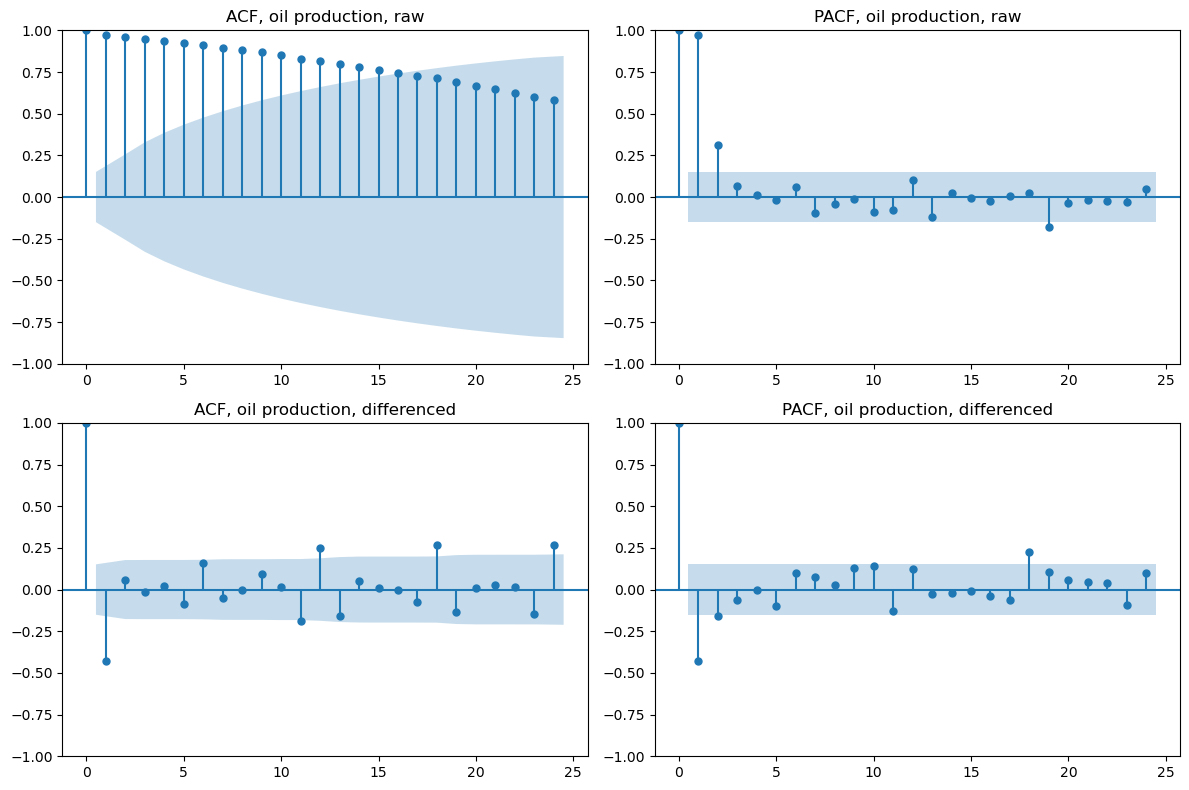

ADF p value, raw: 0.5014
ADF p value, differenced: 0.0000


In [5]:
oil_diff = df.oil_sold_bbl.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(df.oil_sold_bbl, lags=24, ax=axes[0, 0])
axes[0, 0].set_title("ACF, oil production, raw")
plot_pacf(df.oil_sold_bbl, lags=24, ax=axes[0, 1])
axes[0, 1].set_title("PACF, oil production, raw")

plot_acf(oil_diff, lags=24, ax=axes[1, 0])
axes[1, 0].set_title("ACF, oil production, differenced")
plot_pacf(oil_diff, lags=24, ax=axes[1, 1])
axes[1, 1].set_title("PACF, oil production, differenced")

plt.tight_layout()
fig.savefig("figures/fig1_oil_stationarity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ADF p value, raw: {adfuller(df.oil_sold_bbl)[1]:.4f}")
print(f"ADF p value, differenced: {adfuller(oil_diff)[1]:.4f}")

## Figure 2 — oil, gas transmission, and VIIRS overlaid on one plot

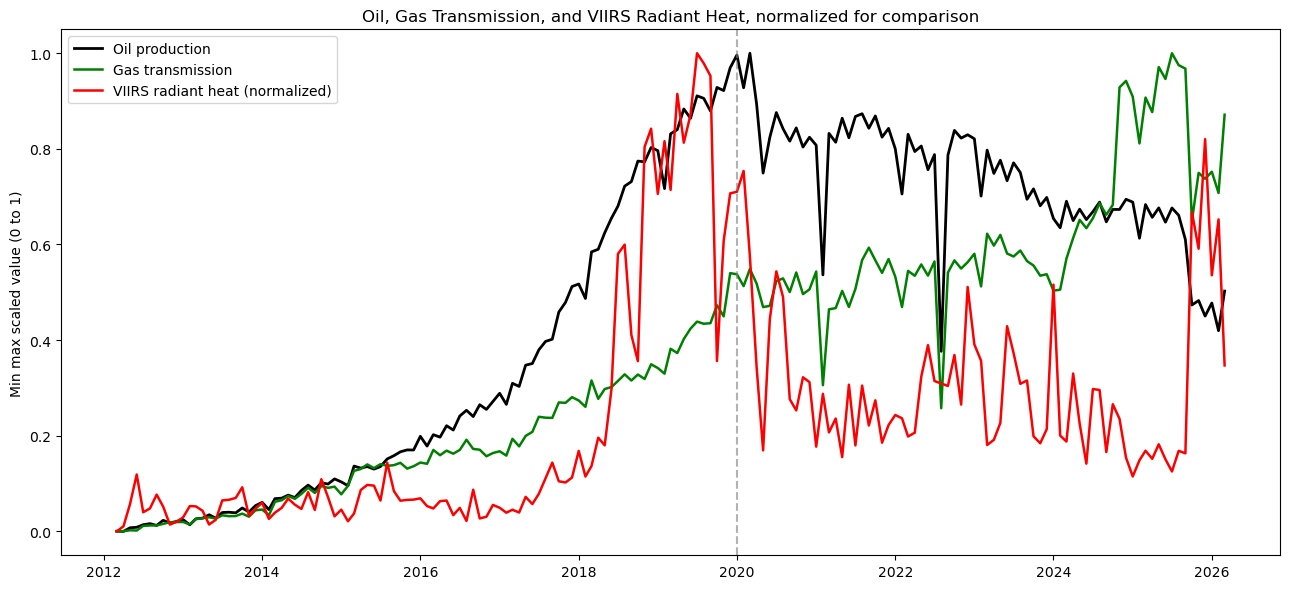

In [6]:
plot_df = df[["date", "oil_sold_bbl", "csgd_transmission_mcf", "rh_per_look"]].copy()
scaler = MinMaxScaler()
plot_df[["oil_norm", "gas_norm", "viirs_norm"]] = scaler.fit_transform(
    plot_df[["oil_sold_bbl", "csgd_transmission_mcf", "rh_per_look"]]
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(plot_df.date, plot_df.oil_norm, color="black", lw=2, label="Oil production")
ax.plot(plot_df.date, plot_df.gas_norm, color="green", lw=1.8, label="Gas transmission")
ax.plot(plot_df.date, plot_df.viirs_norm, color="red", lw=1.8, label="VIIRS radiant heat (normalized)")
ax.axvline(pd.Timestamp("2020-01-01"), color="gray", ls="--", alpha=0.6)
ax.set_ylabel("Min max scaled value (0 to 1)")
ax.set_title("Oil, Gas Transmission, and VIIRS Radiant Heat, normalized for comparison")
ax.legend()
plt.tight_layout()
fig.savefig("figures/fig2_three_series.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 — held out forecast: baseline, log ARIMA, VIIRS, and gas transmission

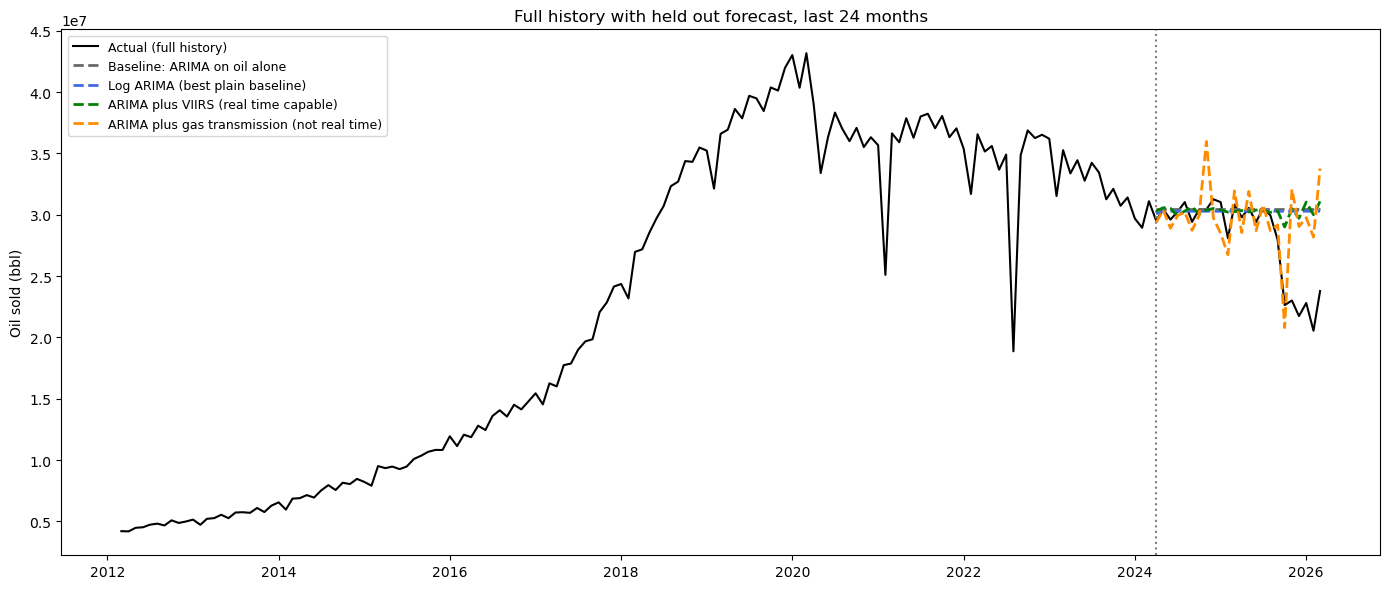

Baseline             RMSE: 4,126,442
Log ARIMA            RMSE: 4,047,053
VIIRS only           RMSE: 4,016,913
Gas transmission     RMSE: 4,066,970


In [7]:
test_size = 24
train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

# 1. Baseline: ARIMA on raw oil alone
baseline_fc = ARIMA(train.oil_sold_bbl, order=(0, 1, 1)).fit().forecast(steps=test_size)

# 2. Log ARIMA: best plain baseline
log_fc = np.exp(ARIMA(train.log_oil, order=(0, 1, 2)).fit().forecast(steps=test_size))

# 3. VIIRS only: best real time capable predictor
train_X_viirs = train[["rh_per_look"]].diff().fillna(0)
test_X_viirs = test[["rh_per_look"]].diff().fillna(0)
viirs_fc = ARIMA(train.oil_sold_bbl, exog=train_X_viirs, order=(0, 1, 1)).fit().forecast(steps=test_size, exog=test_X_viirs)

# 4. Gas transmission: strongest model overall, shown for reference, not real time
train_X_gas = train[["csgd_transmission_mcf"]].diff().fillna(0)
test_X_gas = test[["csgd_transmission_mcf"]].diff().fillna(0)
gas_fc = ARIMA(train.oil_sold_bbl, exog=train_X_gas, order=(0, 1, 1)).fit().forecast(steps=test_size, exog=test_X_gas)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.date, df.oil_sold_bbl, color="black", lw=1.5, label="Actual (full history)")
ax.axvline(test.date.iloc[0], color="gray", ls=":", lw=1.5)

ax.plot(test.date, baseline_fc.values, color="dimgray", ls="--", lw=2, label="Baseline: ARIMA on oil alone")
ax.plot(test.date, log_fc.values, color="royalblue", ls="--", lw=2, label="Log ARIMA (best plain baseline)")
ax.plot(test.date, viirs_fc.values, color="green", ls="--", lw=2, label="ARIMA plus VIIRS (real time capable)")
ax.plot(test.date, gas_fc.values, color="darkorange", ls="--", lw=2, label="ARIMA plus gas transmission (not real time)")

ax.set_ylabel("Oil sold (bbl)")
ax.set_title("Full history with held out forecast, last 24 months")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
fig.savefig("figures/fig4_forecast_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

for name, fc in [("Baseline", baseline_fc), ("Log ARIMA", log_fc), ("VIIRS only", viirs_fc), ("Gas transmission", gas_fc)]:
    rmse = np.sqrt(mean_squared_error(test.oil_sold_bbl, fc))
    print(f"{name:<20} RMSE: {rmse:,.0f}")

## Figure 4 — oil vs each signal, colored by year, linear and quadratic fit

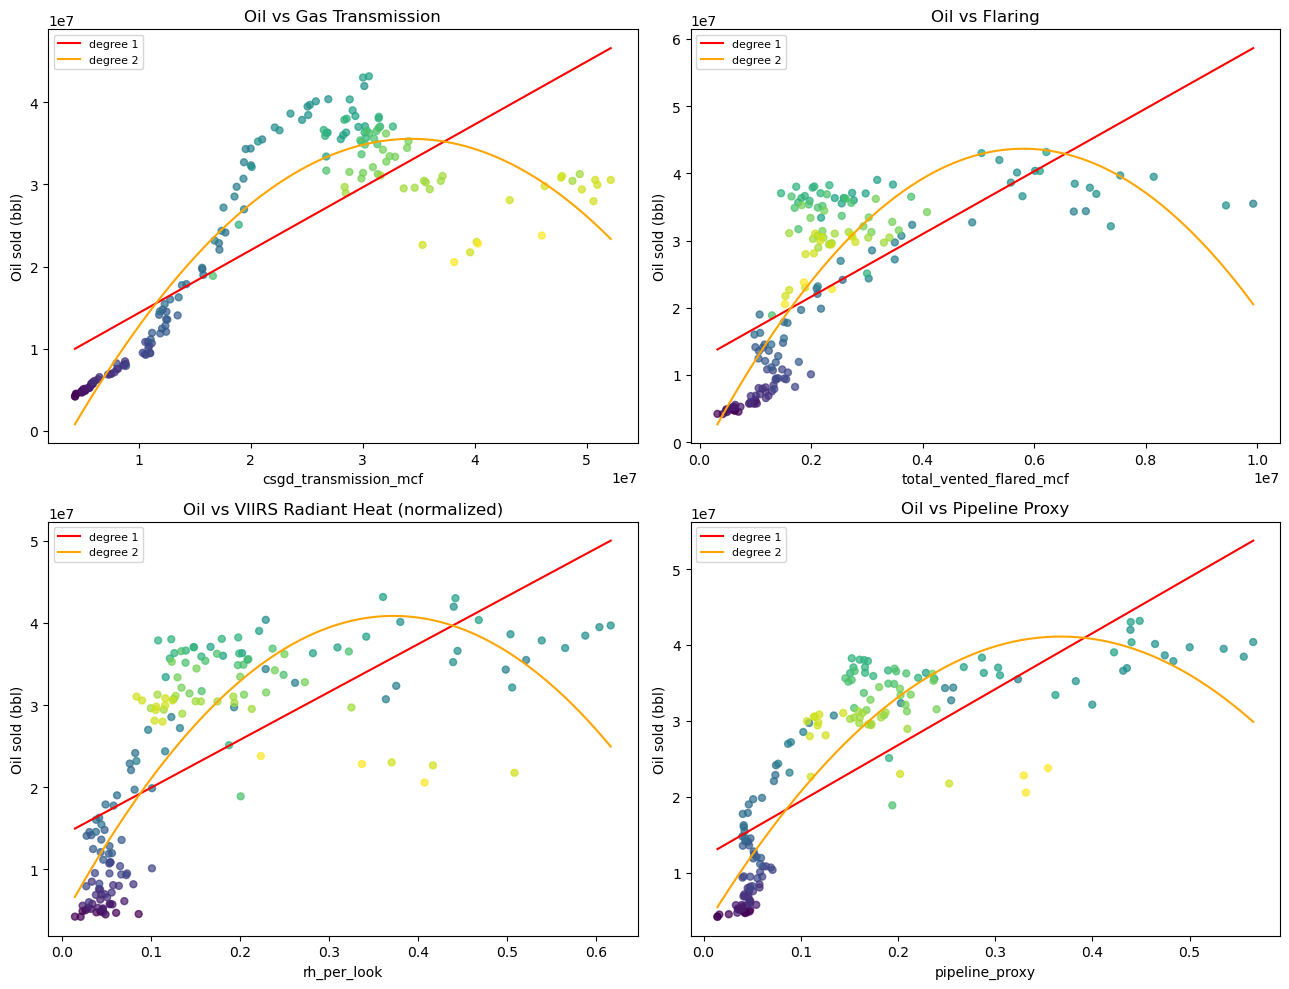

In [8]:
pairs = [
    ("csgd_transmission_mcf", "Gas Transmission"),
    ("total_vented_flared_mcf", "Flaring"),
    ("rh_per_look", "VIIRS Radiant Heat (normalized)"),
    ("pipeline_proxy", "Pipeline Proxy"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (col, title) in zip(axes.flat, pairs):
    x, y = df[col].values, df["oil_sold_bbl"].values
    ax.scatter(x, y, c=df.year, cmap="viridis", s=25, alpha=0.7)
    for deg, color in [(1, "red"), (2, "orange")]:
        coefs = np.polyfit(x, y, deg)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, np.polyval(coefs, x_line), color=color, label=f"degree {deg}")
    ax.set_xlabel(col)
    ax.set_ylabel("Oil sold (bbl)")
    ax.set_title(f"Oil vs {title}")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig("figures/fig3_nonlinear_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 5 — oil vs pipeline proxy, split into rising and falling arms

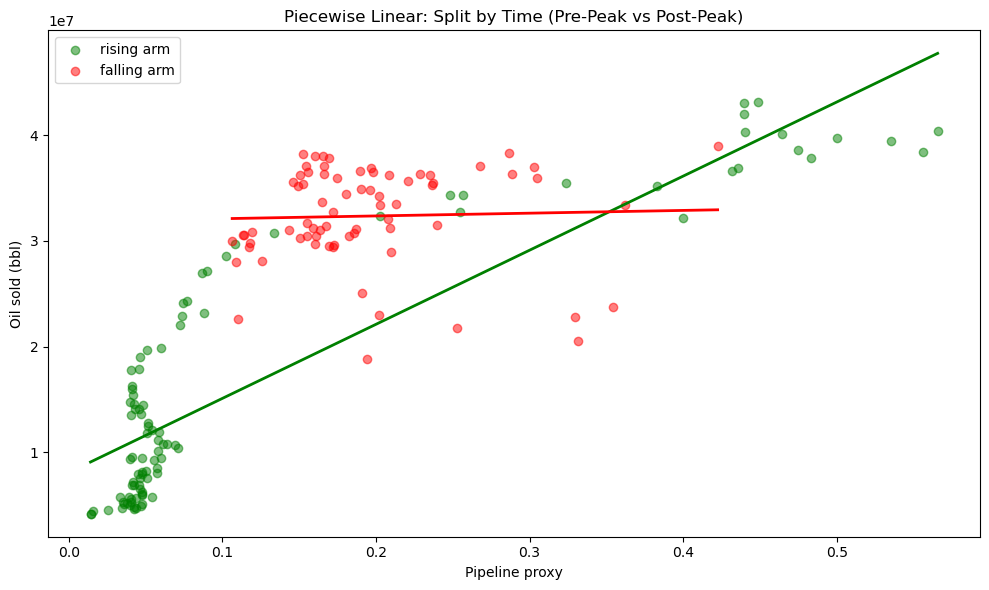

In [9]:
peak_idx = df["oil_sold_bbl"].idxmax()
df["arm_time"] = np.where(df["date"] <= df.loc[peak_idx, "date"], "rising", "falling")

fig, ax = plt.subplots(figsize=(10, 6))
for arm, color in [("rising", "green"), ("falling", "red")]:
    sub = df[df.arm_time == arm]
    ax.scatter(sub.pipeline_proxy, sub.oil_sold_bbl, alpha=0.5, color=color, label=f"{arm} arm")
    coefs = np.polyfit(sub.pipeline_proxy, sub.oil_sold_bbl, 1)
    x_line = np.linspace(sub.pipeline_proxy.min(), sub.pipeline_proxy.max(), 50)
    ax.plot(x_line, np.polyval(coefs, x_line), color=color, linewidth=2)

ax.set_xlabel("Pipeline proxy")
ax.set_ylabel("Oil sold (bbl)")
ax.legend()
ax.set_title("Piecewise Linear: Split by Time (Pre-Peak vs Post-Peak)")
plt.tight_layout()
fig.savefig("figures/fig5_piecewise_arms.png", dpi=150, bbox_inches="tight")
plt.show()